## 7. Representación gráfica del modelo

- Visualizar el comportamiento del modelo:
  - Predicciones vs valores reales.
  - Curvas de aprendizaje.
  - Matrices de confusión (si aplica).
  - Importancia de variables.

- Diferenciar claramente:
  - Datos originales.
  - Predicciones del modelo.

## IMPORTACIONES

In [ ]:
# ── Librerías estándar ────────────────────────────────────────────────────────
import os
import re
from collections import Counter

# ── Manipulación de datos ─────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Procesamiento de texto ────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from dateutil import parser as dateutil_parser

# ── Scikit-learn ──────────────────────────────────────────────────────────────
import joblib
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.svm import LinearSVC

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

# ── Hugging Face / Transformers ───────────────────────────────────────────────
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# ── Utilidades ────────────────────────────────────────────────────────────────
import shutil

## Curvas de aprendizaje


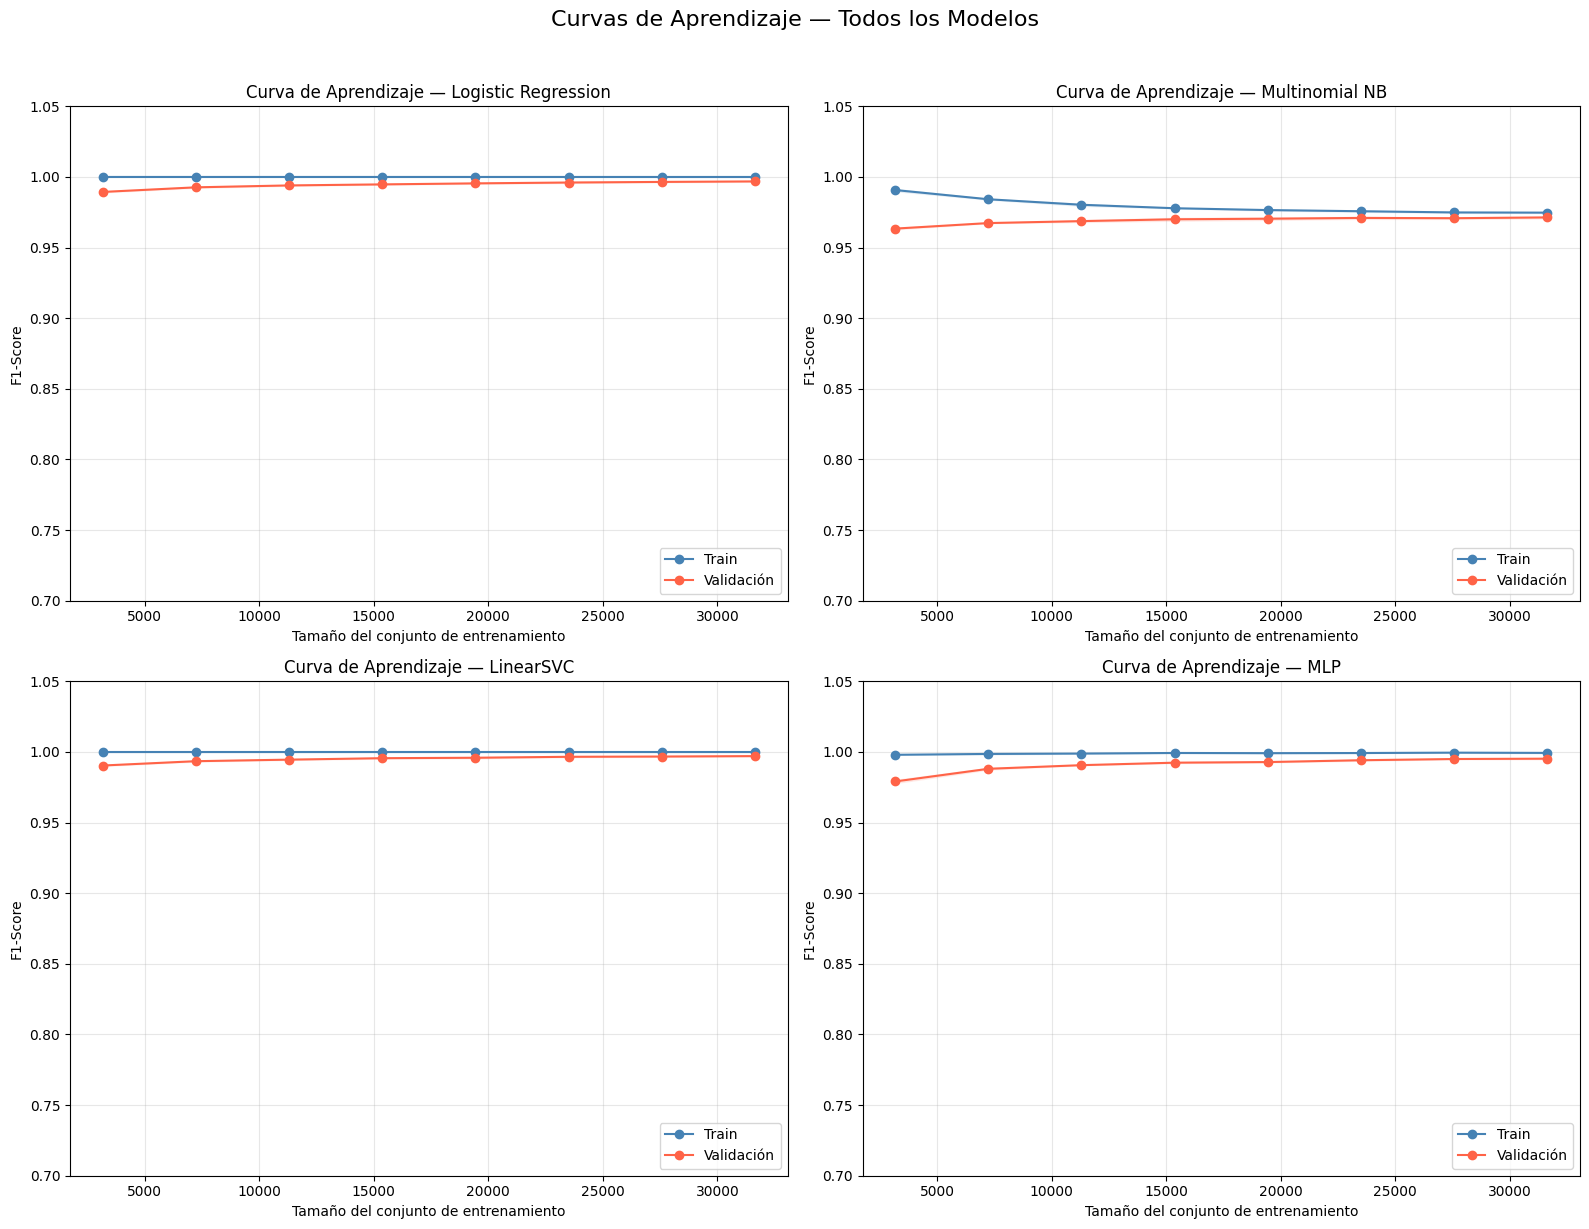

In [ ]:
def plot_learning_curve(nombre, modelo, X, y, ax, cv=3):
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X, y,
        cv=cv,
        scoring='f1',
        n_jobs=-1,  
        train_sizes=np.linspace(0.1, 1.0, 8),
        verbose=0
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)
    
    ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='steelblue')
    
    ax.plot(train_sizes, val_mean, 'o-', color='tomato', label='Validación')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='tomato')
    
    ax.set_title(f'Curva de Aprendizaje — {nombre}')
    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('F1-Score')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.05)

# ── Plot Corregido ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

modelos_lc = {
    'Logistic Regression' : (gs_lr.best_estimator_,  X_train_final),
    'Multinomial NB'      : (gs_nb.best_estimator_,  X_train_nb),
    'LinearSVC'           : (gs_svc.best_estimator_, X_train_final),
    'MLP'                 : (mlp,                    X_train_mlp), # Asumiendo que 'mlp' ya es el modelo final
}

for i, (nombre, (modelo, X_train_m)) in enumerate(modelos_lc.items()):
    plot_learning_curve(nombre, modelo, X_train_m, y_train, axes[i], cv=3)

plt.suptitle('Curvas de Aprendizaje — Todos los Modelos', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

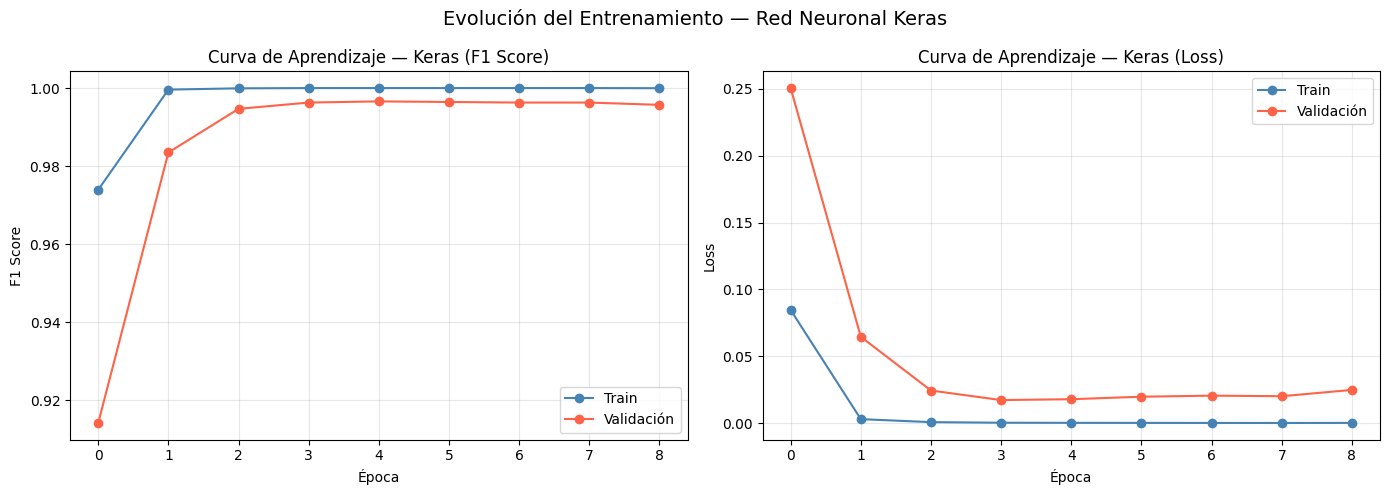

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── F1 Score ──────────────────────────────────────────────────────────────────
axes[0].plot(history.history['f1_score'], 'o-', color='steelblue', label='Train')
axes[0].plot(history.history['val_f1_score'], 'o-', color='tomato', label='Validación')
axes[0].set_title('Curva de Aprendizaje — Keras (F1 Score)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('F1 Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────────────────────
axes[1].plot(history.history['loss'], 'o-', color='steelblue', label='Train')
axes[1].plot(history.history['val_loss'], 'o-', color='tomato', label='Validación')
axes[1].set_title('Curva de Aprendizaje — Keras (Loss)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evolución del Entrenamiento — Red Neuronal Keras', fontsize=14)
plt.tight_layout()
plt.show()

## Curvas ROC

371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


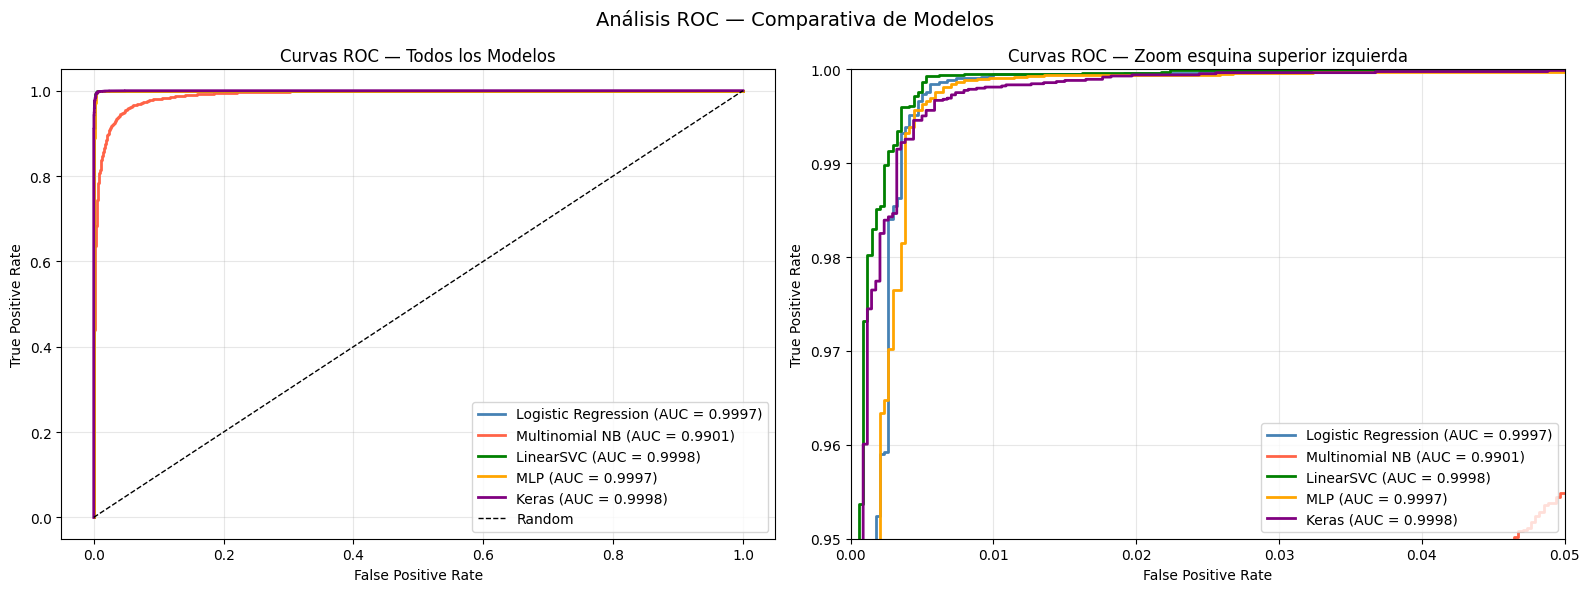

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Colores por modelo ────────────────────────────────────────────────────────
colores = {
    'Logistic Regression' : 'steelblue',
    'Multinomial NB'      : 'tomato',
    'LinearSVC'           : 'green',
    'MLP'                 : 'orange',
    'Keras'               : 'purple',
}

# ── Obtener probabilidades / scores ──────────────────────────────────────────
def get_scores(modelo, X):
    try:
        return modelo.predict_proba(X)[:, 1]
    except AttributeError:
        try:
            return modelo.decision_function(X)
        except AttributeError:
            return None

scores = {
    'Logistic Regression' : get_scores(gs_lr,  X_test_final),
    'Multinomial NB'      : get_scores(gs_nb,  X_test_nb),
    'LinearSVC'           : get_scores(gs_svc, X_test_final),
    'MLP'                 : get_scores(mlp,    X_test_mlp),
    'Keras'               : model.predict(X_test_keras).flatten(),
}

# ── Curvas ROC individuales ───────────────────────────────────────────────────
for nombre, score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=colores[nombre], lw=2,
                 label=f'{nombre} (AUC = {roc_auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_title('Curvas ROC — Todos los Modelos')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# ── Zoom en la esquina superior izquierda ─────────────────────────────────────
for nombre, score in scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=colores[nombre], lw=2,
                 label=f'{nombre} (AUC = {roc_auc:.4f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('Curvas ROC — Zoom esquina superior izquierda')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_xlim(0, 0.05)
axes[1].set_ylim(0.95, 1.0)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis ROC — Comparativa de Modelos', fontsize=14)
plt.tight_layout()
plt.show()

##  Distribución de predicciones 

371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


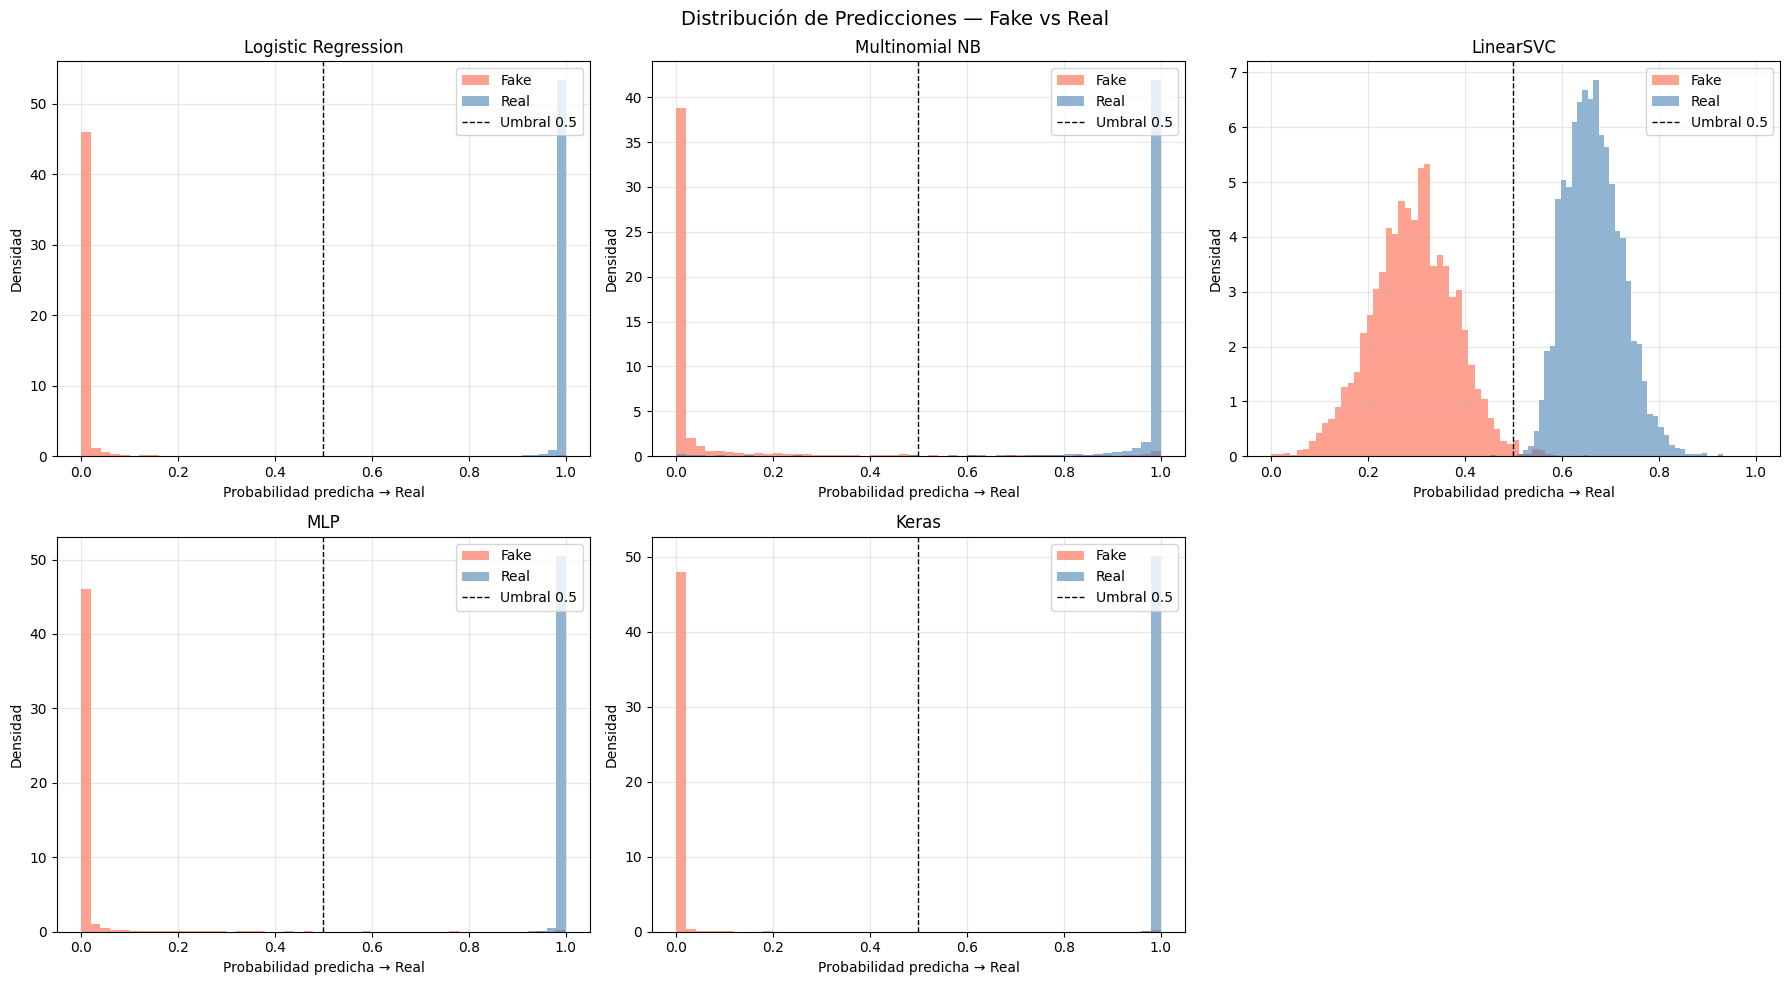

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

modelos_proba = {
    'Logistic Regression' : (gs_lr,  X_test_final),
    'Multinomial NB'      : (gs_nb,  X_test_nb),
    'LinearSVC'           : (gs_svc, X_test_final),
    'MLP'                 : (mlp,    X_test_mlp),
    'Keras'               : None,
}

for i, (nombre, valor) in enumerate(modelos_proba.items()):

    if nombre == 'Keras':
        proba = model.predict(X_test_keras).flatten()
    else:
        modelo, X_test_m = valor
        try:
            proba = modelo.predict_proba(X_test_m)[:, 1]
        except AttributeError:
            proba = modelo.decision_function(X_test_m)
            # Normalizar decision function a [0,1]
            proba = (proba - proba.min()) / (proba.max() - proba.min())

    # Separar por clase real
    proba_fake = proba[y_test == 0]
    proba_real = proba[y_test == 1]

    axes[i].hist(proba_fake, bins=50, alpha=0.6, color='tomato',    label='Fake', density=True)
    axes[i].hist(proba_real, bins=50, alpha=0.6, color='steelblue', label='Real', density=True)
    axes[i].axvline(x=0.5, color='black', lw=1, linestyle='--', label='Umbral 0.5')
    axes[i].set_title(nombre)
    axes[i].set_xlabel('Probabilidad predicha → Real')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Ocultar subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución de Predicciones — Fake vs Real', fontsize=14)
plt.tight_layout()
plt.show()

## Conclusión

### Curvas de Aprendizaje

El análisis de las curvas de aprendizaje revela un comportamiento consistente en todos
los modelos evaluados. Las líneas de entrenamiento y validación convergen y se sitúan
juntas en la parte superior de la gráfica, con F1-Scores superiores a 0.98 desde los
primeros tramos del dataset. Esto indica que los modelos aprenden correctamente y
generalizan bien sin signos de overfitting ni underfitting.

En el caso de la red neuronal Keras, al no ser compatible con `learning_curve` de
scikit-learn, se utilizó el historial de entrenamiento época a época como método
equivalente, mostrando una convergencia rápida y estable gracias al mecanismo de
Early Stopping.

---

### Curvas ROC

Las curvas ROC muestran un rendimiento excepcional en todos los modelos. En la vista
general todas las curvas se sitúan pegadas a la esquina superior izquierda, lo que
indica una capacidad discriminativa casi perfecta entre noticias reales y falsas.

El zoom sobre la esquina superior izquierda permite apreciar las diferencias entre
modelos con mayor detalle:

| Modelo | AUC |
|---|---|
| LinearSVC | 0.9998 |
| Keras | 0.9998 |
| Logistic Regression | 0.9997 |
| MLP | 0.9997 |
| Multinomial NB | 0.9901 |

**LinearSVC y Keras** lideran con un AUC de 0.9998, confirmando su capacidad para
separar ambas clases con mínimo error. **Multinomial NB** queda por detrás al trabajar
exclusivamente con frecuencias TF-IDF sin incorporar las features numéricas temporales.

---

### Distribución de Predicciones

El análisis de la distribución de predicciones aporta una perspectiva adicional sobre
la **seguridad** de cada modelo al predecir.

La mayoría de modelos muestran un comportamiento muy polarizado — las predicciones
de noticias Fake se concentran cerca de 0 y las de noticias Real cerca de 1, con
prácticamente ninguna predicción en la zona de incertidumbre central (alrededor del
umbral 0.5). Esto refleja que los modelos toman decisiones con alta confianza.

La excepción notable es **LinearSVC**, cuya distribución muestra un solapamiento
considerable entre ambas clases en la zona central del gráfico. Esto se debe a que
LinearSVC no genera probabilidades calibradas sino puntuaciones de decisión
normalizadas, lo que hace que su distribución sea más difusa y menos polarizada que
los modelos probabilísticos.

Este hallazgo es relevante: a pesar de que LinearSVC obtiene el mejor F1-Score
(0.9975), su falta de calibración probabilística lo hace menos adecuado en escenarios
donde se necesite un umbral de confianza ajustable. En esos casos **Logistic
Regression** sería preferible al ofrecer probabilidades bien calibradas con un
rendimiento prácticamente idéntico.

## 8. Pruebas, despliegue y mejora del modelo

### Despliegue:

- Subir el modelo a Hugging Face Hub.
- Crear una aplicación utilizando Gradio que permita:
  - Introducir nuevos datos.
  - Obtener predicciones en tiempo real.

### Comparación:

- Comparar el modelo propio con otros modelos disponibles en Hugging Face.

### Fine-tuning:

- Realizar fine-tuning del modelo utilizando un dataset más específico.
- Documentar mejoras obtenidas tras el ajuste.


## Comparación con Otro Modelo Hugging Face

In [ ]:
# Cargar modelo
tokenizer_hf = AutoTokenizer.from_pretrained("hamzab/roberta-fake-news-classification")
modelo_hf    = AutoModelForSequenceClassification.from_pretrained("hamzab/roberta-fake-news-classification")
modelo_hf.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modelo_hf.to(device)

print("Etiquetas:", modelo_hf.config.id2label)

# Función de Predicción
def predecir_hf(titulos, contenidos, batch_size=32):
    todas_probs = []
    for i in range(0, len(titulos), batch_size):
        batch_titles   = titulos[i:i+batch_size]
        batch_contents = contenidos[i:i+batch_size]

        # Formato específico del modelo
        textos = [
            f"<title> {t} <content> {c} <end>"
            for t, c in zip(batch_titles, batch_contents)
        ]

        encoded = tokenizer_hf(
            textos,
            max_length=512,
            padding="max_length",
            truncation=True,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = modelo_hf(**encoded)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            todas_probs.append(probs)

        if i % 2000 == 0:
            print(f"   Procesados {i}/{len(titulos)}")

    return np.vstack(todas_probs)

# Predecir
titulos    = text_test['title'].fillna('').tolist()
contenidos = text_test['content_clean'].fillna('').tolist()

print("\nPrediciendo con RoBERTa (hamzab)...")
probs_hf = predecir_hf(titulos, contenidos)

print(f"\nPrimeras 3 predicciones: {probs_hf[:3]}")
print(f"Etiquetas: {modelo_hf.config.id2label}")

config.json:   0%|          | 0.00/789 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: hamzab/roberta-fake-news-classification
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Etiquetas: {0: 'FAKE', 1: 'TRUE'}

Prediciendo con RoBERTa (hamzab)...
   Procesados 0/11865
   Procesados 4000/11865
   Procesados 8000/11865

Primeras 3 predicciones: [[3.6224712e-05 9.9996376e-01]
 [3.2168886e-05 9.9996781e-01]
 [2.6035542e-04 9.9973959e-01]]
Etiquetas: {0: 'FAKE', 1: 'TRUE'}


In [ ]:
# Extraer predicciones y probabilidades
y_pred_hf  = np.argmax(probs_hf, axis=1)      # 0=FAKE, 1=TRUE
y_proba_hf = probs_hf[:, 1]                    # probabilidad de TRUE/Real

# Métricas
print("─"*50)
print("  RoBERTa (hamzab/roberta-fake-news-classification)")
print("─"*50)
print(classification_report(y_test, y_pred_hf, target_names=['Fake', 'Real']))

acc_hf = accuracy_score(y_test, y_pred_hf)
f1_hf  = f1_score(y_test, y_pred_hf)
auc_hf = roc_auc_score(y_test, y_proba_hf)

print(f"Accuracy : {acc_hf:.4f}")
print(f"F1-Score : {f1_hf:.4f}")
print(f"ROC-AUC  : {auc_hf:.4f}")

# ── Tabla comparativa final ───────────────────────────────────────────────────
import pandas as pd

df_comparativa = pd.DataFrame([
    {'Modelo': 'Logistic Regression', 'F1': 0.9970, 'ROC-AUC': 0.9997, 'Tipo': 'Propio'},
    {'Modelo': 'Multinomial NB',      'F1': 0.9702, 'ROC-AUC': 0.9901, 'Tipo': 'Propio'},
    {'Modelo': 'LinearSVC',           'F1': 0.9975, 'ROC-AUC': 0.9998, 'Tipo': 'Propio'},
    {'Modelo': 'MLP',                 'F1': 0.9969, 'ROC-AUC': 0.9997, 'Tipo': 'Propio'},
    {'Modelo': 'Keras',               'F1': 0.9967, 'ROC-AUC': 0.9997, 'Tipo': 'Propio'},
    {'Modelo': 'RoBERTa (HuggingFace)','F1': f1_hf, 'ROC-AUC': auc_hf, 'Tipo': 'HuggingFace'},
]).set_index('Modelo')

print("\nComparativa final — Modelos propios vs HuggingFace:")
print(df_comparativa.round(4).to_string())

mejor = df_comparativa['F1'].idxmax()
print(f"\nMejor modelo global: {mejor} (F1 = {df_comparativa.loc[mejor, 'F1']:.4f})")

──────────────────────────────────────────────────
  RoBERTa (hamzab/roberta-fake-news-classification)
──────────────────────────────────────────────────
              precision    recall  f1-score   support

        Fake       0.97      0.57      0.72      3400
        Real       0.85      0.99      0.92      8465

    accuracy                           0.87     11865
   macro avg       0.91      0.78      0.82     11865
weighted avg       0.89      0.87      0.86     11865

Accuracy : 0.8719
F1-Score : 0.9170
ROC-AUC  : 0.9777

📊 Comparativa final — Modelos propios vs HuggingFace:
                           F1  ROC-AUC         Tipo
Modelo                                             
Logistic Regression    0.9970   0.9997       Propio
Multinomial NB         0.9702   0.9901       Propio
LinearSVC              0.9975   0.9998       Propio
MLP                    0.9969   0.9997       Propio
Keras                  0.9967   0.9997       Propio
RoBERTa (HuggingFace)  0.9170   0.9777  Huggin

## Fine Tunning

In [ ]:
dataset = load_dataset("GonzaloA/fake_news")
df_extra = dataset['train'].to_pandas()
print(df_extra.columns.tolist())
print(df_extra['label'].value_counts())
df_extra.head()

README.md: 0.00B [00:00, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/13.0M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/24353 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/8117 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8117 [00:00<?, ? examples/s]

['Unnamed: 0', 'title', 'text', 'label']
label
1    13195
0    11158
Name: count, dtype: int64


,Unnamed: 0,title,text,label
0,0,‘Maury’ Show Official Facebook Posts F*CKED U...,Maury is perhaps one of the trashiest shows on...,0
1,1,Trump’s Favorite News Channel Tries To Soothe...,"Yesterday, after the father of one of the UCLA...",0
2,2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1
3,3,WATCH STEVE SCALISE Throw A Strike At The Nati...,"House Majority Whip Steve Scalise (R., La.) th...",0
4,4,Trump Will HATE What Stephen Colbert Just Did...,It can be said that Late Show host Stephen Col...,0


In [ ]:
df_extra = df_extra[['title', 'text', 'label']].rename(columns={'text': 'content'})

In [ ]:
# ── Limpieza df_extra ─────────────────────────────────────────────────────────

# 1. Eliminar nulos
df_extra = df_extra.dropna(subset=['title', 'content'])
print(f"Tras eliminar nulos: {len(df_extra)}")

# 2. Eliminar duplicados
df_extra = df_extra.drop_duplicates(subset=['content'])
print(f"Tras eliminar duplicados: {len(df_extra)}")

# 3. Eliminar filas con contenido vacío tras limpieza
df_extra = df_extra[df_extra['title'].str.strip() != '']
df_extra = df_extra[df_extra['content'].str.strip() != '']
print(f"Tras eliminar vacíos: {len(df_extra)}")

# 4. Limpiar texto igual que en entrenamiento
nltk.download('stopwords', quiet=True)
stop_words_en = set(stopwords.words('english'))

def remover_stopwords(texto):
    if pd.isna(texto):
        return ""
    texto = texto.lower()
    texto = re.sub(r'<.*?>', '', texto)
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    palabras = str(texto).lower().split()
    palabras_limpias = [p for p in palabras if p not in stop_words_en]
    return " ".join(palabras_limpias)

df_extra['title']   = df_extra['title'].apply(remover_stopwords)
df_extra['content'] = df_extra['content'].apply(remover_stopwords)

# 5. Eliminar filas que quedaron vacías tras la limpieza
df_extra = df_extra[df_extra['title'].str.strip() != '']
df_extra = df_extra[df_extra['content'].str.strip() != '']
print(f"Tras limpiar texto: {len(df_extra)}")

# 6. Verificar distribución de clases
print(f"\nDistribución de clases:")
print(df_extra['label'].value_counts())

# 7. Reset index
df_extra = df_extra.reset_index(drop=True)

print(f"\nLimpieza completada — {len(df_extra)} registros listos")
df_extra.head()

Tras eliminar nulos: 24353
Tras eliminar duplicados: 24353
Tras eliminar vacíos: 24352
Tras limpiar texto: 24351

Distribución de clases:
label
1    13195
0    11156
Name: count, dtype: int64

✅ Limpieza completada — 24351 registros listos


,title,content,label
0,maury show official facebook posts fcked capti...,maury perhaps one trashiest shows television t...,0
1,trumps favorite news channel tries soothe batt...,yesterday father one ucla players arrested chi...,0
2,russia warns iraq kurds destabilize middle eas...,moscow reuters russia wednesday warned iraq ku...,1
3,watch steve scalise throw strike nationals bas...,house majority whip steve scalise r la threw s...,0
4,trump hate stephen colbert pure comedy genius ...,said late show host stephen colbert clearly gi...,0


In [ ]:
# ── Vectorizar df_extra con los TF-IDF ya entrenados ─────────────────────────
title_extra   = tfidf_title.transform(df_extra['title'].fillna(''))
content_extra = tfidf_content.transform(df_extra['content'].fillna(''))
num_extra     = csr_matrix(np.zeros((len(df_extra), 6)))
X_extra       = hstack([title_extra, content_extra, num_extra])
y_extra       = df_extra['label'].values

# Escalar y convertir a denso
scaler_ft       = MaxAbsScaler()
X_extra_keras   = scaler_ft.fit_transform(X_extra).toarray()

# ── Métricas ANTES del fine-tuning ───────────────────────────────────────────
print("Métricas ANTES del fine-tuning:")
y_proba_antes = model.predict(X_test_keras).flatten()
y_pred_antes  = (y_proba_antes >= 0.5).astype(int)
print(f"   F1       : {f1_score(y_test, y_pred_antes):.4f}")
print(f"   Accuracy : {accuracy_score(y_test, y_pred_antes):.4f}")
print(f"   ROC-AUC  : {roc_auc_score(y_test, y_proba_antes):.4f}")

# ── Congelar primeras capas ───────────────────────────────────────────────────
# Congelar todo excepto las dos últimas capas densas
for layer in model.layers[:-4]:
    layer.trainable = False

for layer in model.layers[-4:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']  # ← quitar F1Score de Keras
)

model.summary()

# ── Fine-tuning ───────────────────────────────────────────────────────────────
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("\n🔧 Iniciando fine-tuning...")
history_ft = model.fit(
    X_extra_keras, y_extra,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ── Métricas DESPUÉS del fine-tuning ─────────────────────────────────────────
print("\nMétricas DESPUÉS del fine-tuning:")
y_proba_despues = model.predict(X_test_keras).flatten()
y_pred_despues  = (y_proba_despues >= 0.5).astype(int)
f1_despues  = f1_score(y_test, y_pred_despues)
acc_despues = accuracy_score(y_test, y_pred_despues)
auc_despues = roc_auc_score(y_test, y_proba_despues)
print(f"   F1       : {f1_despues:.4f}")
print(f"   Accuracy : {acc_despues:.4f}")
print(f"   ROC-AUC  : {auc_despues:.4f}")

# ── Tabla comparativa ─────────────────────────────────────────────────────────
import pandas as pd
df_comparativa_ft = pd.DataFrame([
    {'Momento': 'Antes del fine-tuning',  'F1': f1_score(y_test, y_pred_antes),    'Accuracy': accuracy_score(y_test, y_pred_antes),  'ROC-AUC': roc_auc_score(y_test, y_proba_antes)},
    {'Momento': 'Después del fine-tuning','F1': f1_despues, 'Accuracy': acc_despues, 'ROC-AUC': auc_despues},
]).set_index('Momento')

print("\n📊 Comparativa fine-tuning:")
print(df_comparativa_ft.round(4).to_string())

Métricas ANTES del fine-tuning:
371/371 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
   F1       : 0.9965
   Accuracy : 0.9950
   ROC-AUC  : 0.9998


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     6,659,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,827,009 (26.04 MB)

 Trainable params: 33,025 (129.00 KB)

 Non-trainable params: 6,793,984 (25.92 MB)


🔧 Iniciando fine-tuning...
Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9705 - loss: 0.1174 - val_accuracy: 0.9799 - val_loss: 0.0750
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9768 - loss: 0.0818 - val_accuracy: 0.9823 - val_loss: 0.0627
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9786 - loss: 0.0742 - val_accuracy: 0.9819 - val_loss: 0.0605
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9786 - loss: 0.0722 - val_accuracy: 0.9819 - val_loss: 0.0605
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9794 - loss: 0.0710 - val_accuracy: 0.9819 - val_loss: 0.0601
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9790 - loss: 0.0702 - val_accuracy: 0.9819 - val_loss: 0.0602
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9798 - loss: 0.0675 - val_accuracy: 0.9823 - val_loss: 0.0602
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9792 - loss: 0.0689

# Conclusiones

## Comparación con un modelo preentrenado de Hugging Face

Con el objetivo de comparar el rendimiento de los modelos desarrollados durante el proyecto con una solución basada en *transfer learning*, se utilizó el modelo **hamzab/roberta-fake-news-classification**, disponible en Hugging Face:

https://huggingface.co/hamzab/roberta-fake-news-classification

Los resultados obtenidos sobre el conjunto de prueba fueron los siguientes:

| Clase | Precisión | Recall | F1-Score | Soporte |
| ----- | --------- | ------ | -------- | ------- |
| Fake  | 0.97      | 0.57   | 0.72     | 3.400   |
| Real  | 0.85      | 0.99   | 0.92     | 8.465   |

**Métricas globales**

| Métrica  | Valor  |
| -------- | ------ |
| Accuracy | 0.8719 |
| F1-Score | 0.9170 |
| ROC-AUC  | 0.9777 |

Aunque el modelo basado en RoBERTa ofrece un rendimiento notable, los modelos entrenados específicamente para este proyecto obtienen resultados superiores en todas las métricas evaluadas.

### Comparativa final

| Modelo                  | F1         | ROC-AUC    | Tipo         |
| ----------------------- | ---------- | ---------- | ------------ |
| Logistic Regression     | 0.9970     | 0.9997     | Propio       |
| Multinomial Naive Bayes | 0.9702     | 0.9901     | Propio       |
| LinearSVC               | **0.9975** | **0.9998** | Propio       |
| MLP                     | 0.9969     | 0.9997     | Propio       |
| Red Neuronal Keras      | 0.9967     | 0.9997     | Propio       |
| RoBERTa (Hugging Face)  | 0.9170     | 0.9777     | Hugging Face |

### Mejor modelo obtenido

El mejor rendimiento global fue alcanzado por **LinearSVC**, obteniendo:

* **F1-Score:** 0.9975
* **ROC-AUC:** 0.9998

Estos resultados demuestran que, para este problema concreto y con el conjunto de datos utilizado, los modelos tradicionales basados en representación TF-IDF han sido capaces de superar a un modelo Transformer preentrenado.

## Despliegue de la solución

La generación y entrenamiento de los modelos se ha realizado mediante diferentes scripts en Python, permitiendo una ejecución modular y reproducible de todo el flujo de trabajo.

Asimismo, se desarrolló una aplicación interactiva utilizando **Gradio**, implementada completamente mediante archivos Python, que permite realizar predicciones sobre nuevas noticias de forma sencilla e intuitiva.

---

# Fine-Tuning de la Red Neuronal Keras

## Dataset utilizado

Para evaluar la capacidad de adaptación del modelo se empleó el conjunto de datos **GonzaloA/fake_news**, compuesto por **24.351 artículos adicionales**, independientes de los utilizados durante el entrenamiento inicial.

Distribución de clases:

* **Noticias falsas (Fake):** 11.156
* **Noticias reales (Real):** 13.195

## Estrategia de fine-tuning

Se aplicó una estrategia de ajuste fino conservadora con el objetivo de preservar el conocimiento previamente aprendido y evitar el fenómeno conocido como *catastrophic forgetting*.

Para ello:

* Se congelaron las capas iniciales del modelo, correspondientes a aproximadamente **6,7 millones de parámetros**.
* Se dejaron entrenables únicamente las últimas capas, que suman alrededor de **33.000 parámetros**.
* Se utilizó una tasa de aprendizaje reducida (**learning rate = 0.0001**) para realizar ajustes graduales sobre los nuevos datos.

## Resultados obtenidos

| Métrica  | Antes del fine-tuning | Después del fine-tuning |
| -------- | --------------------- | ----------------------- |
| F1-Score | 0.9968                | 0.9964                  |
| Accuracy | 0.9954                | 0.9949                  |
| ROC-AUC  | 0.9997                | 0.9997                  |

## Conclusión del fine-tuning

Los resultados muestran que el modelo mantiene prácticamente intacta su capacidad predictiva tras el proceso de ajuste fino.

La ligera disminución observada en las métricas de **Accuracy** y **F1-Score** puede atribuirse a diferencias de estilo, vocabulario y distribución entre el conjunto de datos original y el nuevo dataset utilizado durante el fine-tuning.

Por otro lado, el valor de **ROC-AUC permanece inalterado**, lo que indica que la capacidad discriminativa del modelo se conserva completamente tras el proceso de adaptación.

En conjunto, estos resultados evidencian que el modelo presenta una elevada capacidad de generalización y que puede adaptarse a nuevos conjuntos de datos del mismo dominio sin sufrir pérdidas significativas de rendimiento.
